In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

# Load cleaned NAV history
nav_history = pd.read_csv(
    "/content/drive/MyDrive/Bluestock /capstone/cleaned/nav_history_cleaned.csv"
)

print(nav_history.shape)
print(nav_history.columns)
print(nav_history.head())

(45962, 3)
Index(['amfi_code', 'date', 'nav'], dtype='object')
   amfi_code        date       nav
0     100016  2022-01-02  512.1124
1     100016  2022-01-03  503.1674
2     100016  2022-01-04  531.2850
3     100016  2022-01-06  474.1732
4     100016  2022-01-07  452.5840


#1 — Daily Returns

In [ ]:
# Calculate daily returns

nav_history['date'] = pd.to_datetime(nav_history['date'])

# Sort data by fund and date
nav_history = nav_history.sort_values(['amfi_code', 'date'])

# Calculate daily return for each fund
nav_history['daily_return'] = (
    nav_history.groupby('amfi_code')['nav'].pct_change()
)

# Display the result
nav_history[['amfi_code', 'date', 'nav', 'daily_return']].head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-02,512.1124,NaN
1,100016,2022-01-03,503.1674,-0.017467
2,100016,2022-01-04,531.2850,0.055881
3,100016,2022-01-06,474.1732,-0.107497
4,100016,2022-01-07,452.5840,-0.045530
5,100016,2022-01-08,433.0211,-0.043225
6,100016,2022-01-09,424.3603,-0.020001
7,100016,2022-01-11,448.4277,0.056715
8,100016,2022-01-12,482.4201,0.075804
9,100016,2022-02-02,515.5386,0.068651


In [ ]:
# Validate daily return distribution

print("Number of schemes:", nav_history['amfi_code'].nunique())
print("Total observations:", len(nav_history))
print("Missing daily returns:", nav_history['daily_return'].isna().sum())

print("\nDaily return statistics:")
print(nav_history['daily_return'].describe())

Number of schemes: 40
Total observations: 45962
Missing daily returns: 40

Daily return statistics:
count    45922.000000
mean         0.002172
std          0.053470
min         -0.732884
25%         -0.007686
50%          0.001325
75%          0.012933
max          0.436832
Name: daily_return, dtype: float64


In [ ]:
# Check extreme daily returns

print("Largest daily returns:")
print(nav_history['daily_return'].nlargest(5))

print("\nSmallest daily returns:")
print(nav_history['daily_return'].nsmallest(5))

Largest daily returns:
24317    0.436832
25453    0.429916
25461    0.424366
25393    0.421722
25384    0.419289
Name: daily_return, dtype: float64

Smallest daily returns:
45265   -0.732884
34918   -0.714692
29169   -0.709766
2744    -0.698587
24570   -0.695653
Name: daily_return, dtype: float64


In [ ]:
# Identify extreme daily returns

extreme_returns = nav_history[
    (nav_history['daily_return'] > 0.20) |
    (nav_history['daily_return'] < -0.20)
].copy()

print("Number of extreme observations:", len(extreme_returns))

print(
    extreme_returns[
        ['amfi_code', 'date', 'nav', 'daily_return']
    ].sort_values('daily_return')
)

Number of extreme observations: 716
       amfi_code       date       nav  daily_return
45265     149324        NaT   82.2508     -0.732884
34918     120843        NaT   49.6108     -0.714692
29169     120505        NaT  137.9373     -0.709766
2744      100033        NaT  105.1666     -0.698587
24570     119598        NaT   97.8131     -0.695653
...          ...        ...       ...           ...
25384     119599 2023-03-01  147.2531      0.419289
25393     119599 2023-04-01  148.0354      0.421722
25461     119599 2023-12-01  158.7171      0.424366
25453     119599 2023-11-01  159.0324      0.429916
24317     119598 2023-12-09  217.4023      0.436832

[716 rows x 4 columns]


In [ ]:
# Check NAV immediately before extreme movements

extreme_codes = extreme_returns['amfi_code'].unique()

check_extremes = nav_history[
    nav_history['amfi_code'].isin(extreme_codes)
].sort_values(['amfi_code', 'date'])

print(check_extremes[['amfi_code', 'date', 'nav', 'daily_return']].tail(30))

       amfi_code date       nav  daily_return
45932     149324  NaT  278.4207      0.036595
45933     149324  NaT  284.5432      0.021990
45934     149324  NaT  284.5756      0.000114
45935     149324  NaT  288.7272      0.014589
45936     149324  NaT  291.9661      0.011218
45937     149324  NaT  303.7606      0.040397
45938     149324  NaT  312.1137      0.027499
45939     149324  NaT  319.8141      0.024672
45940     149324  NaT  324.3339      0.014133
45941     149324  NaT  320.0778     -0.013123
45942     149324  NaT  321.8379      0.005499
45943     149324  NaT  333.7248      0.036934
45944     149324  NaT  336.6937      0.008896
45945     149324  NaT  332.6546     -0.011996
45946     149324  NaT  334.7114      0.006183
45947     149324  NaT  329.8233     -0.014604
45948     149324  NaT  325.6901     -0.012532
45949     149324  NaT  308.5766     -0.052545
45950     149324  NaT  300.4231     -0.026423
45951     149324  NaT  295.9534     -0.014878
45952     149324  NaT  295.9317   

In [ ]:
# Check rows with invalid dates

invalid_dates = nav_history[nav_history['date'].isna()]

print("Rows with invalid dates:", len(invalid_dates))

print(
    invalid_dates[
        ['amfi_code', 'date', 'nav', 'daily_return']
    ].head(20)
)

Rows with invalid dates: 27842
     amfi_code date       nav  daily_return
453     100016  NaT  510.2445     -0.118176
454     100016  NaT  514.3636      0.008073
455     100016  NaT  514.7627      0.000776
456     100016  NaT  517.3803      0.005085
457     100016  NaT  513.1866     -0.008106
458     100016  NaT  507.1294     -0.011803
459     100016  NaT  507.8710      0.001462
460     100016  NaT  506.7062     -0.002293
461     100016  NaT  509.7762      0.006059
462     100016  NaT  509.6800     -0.000189
463     100016  NaT  510.8661      0.002327
464     100016  NaT  503.8641     -0.013706
465     100016  NaT  512.5903      0.017319
466     100016  NaT  507.5435     -0.009846
467     100016  NaT  504.7492     -0.005506
468     100016  NaT  507.0506      0.004559
469     100016  NaT  516.7872      0.019202
470     100016  NaT  516.4246     -0.000702
471     100016  NaT  519.3918      0.005746
472     100016  NaT  519.1698     -0.000427


In [ ]:
# Check the original date values causing the issue

raw_nav = pd.read_csv(
    "/content/drive/MyDrive/Bluestock /capstone/cleaned/nav_history_cleaned.csv"
)

raw_dates = pd.to_datetime(raw_nav['date'], errors='coerce')

print("Invalid date values:")
print(raw_nav.loc[raw_dates.isna(), 'date'].head(20))

Invalid date values:
453    NaN
454    NaN
455    NaN
456    NaN
457    NaN
458    NaN
459    NaN
460    NaN
461    NaN
462    NaN
463    NaN
464    NaN
465    NaN
466    NaN
467    NaN
468    NaN
469    NaN
470    NaN
471    NaN
472    NaN
Name: date, dtype: object


In [ ]:
# Check missing dates in NAV history

print("Total rows with missing dates:", nav_history['date'].isna().sum())

print("\nMissing dates by scheme:")
print(
    nav_history[nav_history['date'].isna()]
    .groupby('amfi_code')
    .size()
    .sort_values(ascending=False)
)

Total rows with missing dates: 27842

Missing dates by scheme:
amfi_code
101206    697
100033    697
102885    697
120503    697
118635    697
118634    697
118632    697
102887    697
148567    697
149323    697
149322    697
120841    697
120507    697
119599    697
119094    697
149324    697
125497    697
125498    697
120844    697
120504    697
120505    697
120506    697
100016    696
101208    696
148568    696
102886    696
101207    696
118633    696
120843    696
120842    696
119598    696
119552    696
148569    696
119095    695
119551    695
119120    694
119093    694
118636    693
119092    692
100025    689
dtype: int64


In [ ]:
# Check the raw NAV history file

raw_nav = pd.read_csv(
    "/content/drive/MyDrive/Bluestock /capstone/raw/1788499983331-4389156d-02_nav_history.csv"
)

print("Raw NAV shape:", raw_nav.shape)
print("Raw NAV columns:", raw_nav.columns.tolist())

print("\nFirst 10 rows:")
print(raw_nav.head(10))

print("\nMissing values:")
print(raw_nav.isna().sum())

Raw NAV shape: (46000, 3)
Raw NAV columns: ['amfi_code', 'date', 'nav']

First 10 rows:
   amfi_code        date      nav
0     119551  2022-01-03  54.3856
1     119551  2022-01-04  54.3474
2     119551  2022-01-05  54.6869
3     119551  2022-01-06  55.4550
4     119551  2022-01-07  55.3692
5     119551  2022-01-10  55.2835
6     119551  2022-01-11  56.0878
7     119551  2022-01-12  56.4978
8     119551  2022-01-13  56.2934
9     119551  2022-01-14  56.5926

Missing values:
amfi_code    0
date         0
nav          0
dtype: int64


In [ ]:
# Reload NAV history from the original raw dataset

nav_history = pd.read_csv(
    "/content/drive/MyDrive/Bluestock /capstone/raw/1788499983331-4389156d-02_nav_history.csv"
)

# Convert date to datetime
nav_history['date'] = pd.to_datetime(nav_history['date'])

# Sort by scheme and date
nav_history = nav_history.sort_values(
    ['amfi_code', 'date']
).reset_index(drop=True)

print("Shape:", nav_history.shape)
print("Number of schemes:", nav_history['amfi_code'].nunique())
print("Missing dates:", nav_history['date'].isna().sum())
print("Missing NAV:", nav_history['nav'].isna().sum())

Shape: (46000, 3)
Number of schemes: 40
Missing dates: 0
Missing NAV: 0


In [ ]:
# Calculate daily returns

nav_history['daily_return'] = (
    nav_history.groupby('amfi_code')['nav'].pct_change()
)

print(
    nav_history[
        ['amfi_code', 'date', 'nav', 'daily_return']
    ].head(10)
)

   amfi_code       date       nav  daily_return
0     100016 2022-01-03  520.4608           NaN
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210
5     100016 2022-01-10  510.7136     -0.008639
6     100016 2022-01-11  513.5542      0.005562
7     100016 2022-01-12  512.3195     -0.002404
8     100016 2022-01-13  510.2445     -0.004050
9     100016 2022-01-14  514.3636      0.008073


In [ ]:
# Validate daily return distribution

print("Number of schemes:", nav_history['amfi_code'].nunique())
print("Total observations:", len(nav_history))
print("Missing daily returns:", nav_history['daily_return'].isna().sum())

print("\nDaily return statistics:")
print(nav_history['daily_return'].describe())

Number of schemes: 40
Total observations: 46000
Missing daily returns: 40

Daily return statistics:
count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


In [ ]:
# Check extreme daily returns

print("Largest daily returns:")
print(nav_history['daily_return'].nlargest(5))

print("\nSmallest daily returns:")
print(nav_history['daily_return'].nsmallest(5))

Largest daily returns:
24745    0.064713
13226    0.059304
5207     0.054851
25566    0.053320
25832    0.051811
Name: daily_return, dtype: float64

Smallest daily returns:
12774   -0.058102
4917    -0.051847
12952   -0.050335
45312   -0.048870
5560    -0.048634
Name: daily_return, dtype: float64


#2 — CAGR

In [ ]:
# Load cleaned fund master

fund_master = pd.read_csv(
    "/content/drive/MyDrive/Bluestock /capstone/cleaned/fund_master_cleaned.csv"
)

print(fund_master.shape)
print(fund_master.columns)
print(fund_master.head())

(40, 15)
Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='object')
   amfi_code       fund_house                                   scheme_name  \
0     119551  SBI Mutual Fund     SBI Bluechip Fund - Regular Plan - Growth   
1     119552  SBI Mutual Fund      SBI Bluechip Fund - Direct Plan - Growth   
2     119598  SBI Mutual Fund    SBI Small Cap Fund - Regular Plan - Growth   
3     119599  SBI Mutual Fund     SBI Small Cap Fund - Direct Plan - Growth   
4     119120  SBI Mutual Fund  SBI Magnum Gilt Fund - Regular Plan - Growth   

  category sub_category     plan launch_date                  benchmark  \
0   Equity    Large Cap  Regular  2006-02-14              NIFTY 100 TRI   
1   Equity    Large Cap   Direct  2013-01-01              NIFTY 100 TRI   
2

In [ ]:
# Prepare NAV data for CAGR calculation

nav_history['date'] = pd.to_datetime(nav_history['date'])

# Check the available date range
print("NAV start date:", nav_history['date'].min())
print("NAV end date:", nav_history['date'].max())

NAV start date: 2022-01-03 00:00:00
NAV end date: 2026-05-29 00:00:00


In [ ]:
# Calculate CAGR for 1-year, 3-year and 5-year periods

def calculate_cagr(group, years):
    end_date = group['date'].max()
    start_target = end_date - pd.DateOffset(years=years)

    # Find the NAV closest to the target start date
    start_row = group.iloc[
        (group['date'] - start_target).abs().argsort()[:1]
    ]

    end_row = group.loc[group['date'].idxmax()]

    start_nav = start_row['nav'].iloc[0]
    end_nav = end_row['nav']

    cagr = (end_nav / start_nav) ** (1 / years) - 1

    return cagr


cagr_results = []

for amfi_code, group in nav_history.groupby('amfi_code'):
    group = group.sort_values('date')

    cagr_1y = calculate_cagr(group, 1)
    cagr_3y = calculate_cagr(group, 3)
    cagr_5y = calculate_cagr(group, 5)

    cagr_results.append({
        'amfi_code': amfi_code,
        'CAGR_1Y': cagr_1y,
        'CAGR_3Y': cagr_3y,
        'CAGR_5Y': cagr_5y
    })

cagr_report = pd.DataFrame(cagr_results)

# Add fund names
cagr_report = cagr_report.merge(
    fund_master[['amfi_code', 'scheme_name']],
    on='amfi_code',
    how='left'
)

# Arrange columns
cagr_report = cagr_report[
    ['amfi_code', 'scheme_name', 'CAGR_1Y', 'CAGR_3Y', 'CAGR_5Y']
]

print(cagr_report)

    amfi_code                                        scheme_name   CAGR_1Y  \
0      100016          HDFC Top 100 Fund - Regular Plan - Growth -0.022243   
1      100025       HDFC Short Term Debt Fund - Regular - Growth  0.037050   
2      100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...  0.532324   
3      101206      ABSL Frontline Equity Fund - Regular - Growth  0.479241   
4      101207             ABSL Small Cap Fund - Regular - Growth -0.239860   
5      101208                ABSL Liquid Fund - Regular - Growth  0.072366   
6      102885         UTI Nifty 50 Index Fund - Regular - Growth  0.202077   
7      102886                UTI Mid Cap Fund - Regular - Growth -0.167975   
8      102887              UTI Flexi Cap Fund - Regular - Growth  0.135831   
9      118632     Nippon India Large Cap Fund - Regular - Growth  0.339810   
10     118633      Nippon India Large Cap Fund - Direct - Growth  0.255400   
11     118634     Nippon India Small Cap Fund - Regular - Growth

In [ ]:
# Display CAGR as percentages

cagr_display = cagr_report.copy()

cagr_display[['CAGR_1Y', 'CAGR_3Y', 'CAGR_5Y']] = (
    cagr_display[['CAGR_1Y', 'CAGR_3Y', 'CAGR_5Y']] * 100
).round(2)

cagr_display

,amfi_code,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-2.22,1.29,2.32
1,100025,HDFC Short Term Debt Fund - Regular - Growth,3.70,3.92,3.91
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,53.23,32.44,26.07
3,101206,ABSL Frontline Equity Fund - Regular - Growth,47.92,28.97,20.44
4,101207,ABSL Small Cap Fund - Regular - Growth,-23.99,-4.15,6.95
5,101208,ABSL Liquid Fund - Regular - Growth,7.24,6.32,5.71
6,102885,UTI Nifty 50 Index Fund - Regular - Growth,20.21,19.67,15.88
7,102886,UTI Mid Cap Fund - Regular - Growth,-16.80,-0.77,1.03
8,102887,UTI Flexi Cap Fund - Regular - Growth,13.58,25.56,14.68
9,118632,Nippon India Large Cap Fund - Regular - Growth,33.98,22.65,20.88


#3 — Sharpe Ratio

In [ ]:
# Calculate Sharpe Ratio for all funds

risk_free_rate = 0.065
trading_days = 252

sharpe_results = []

for amfi_code, group in nav_history.groupby('amfi_code'):
    returns = group['daily_return'].dropna()

    annualized_return = returns.mean() * trading_days
    annualized_std = returns.std() * (trading_days ** 0.5)

    sharpe_ratio = (
        (annualized_return - risk_free_rate)
        / annualized_std
    )

    sharpe_results.append({
        'amfi_code': amfi_code,
        'Sharpe_Ratio': sharpe_ratio
    })

sharpe_report = pd.DataFrame(sharpe_results)

# Add fund names
sharpe_report = sharpe_report.merge(
    fund_master[['amfi_code', 'scheme_name']],
    on='amfi_code',
    how='left'
)

# Rank funds by Sharpe Ratio
sharpe_report['Sharpe_Rank'] = (
    sharpe_report['Sharpe_Ratio']
    .rank(ascending=False, method='min')
    .astype(int)
)

sharpe_report = sharpe_report.sort_values(
    'Sharpe_Rank'
).reset_index(drop=True)

sharpe_report

,amfi_code,Sharpe_Ratio,scheme_name,Sharpe_Rank
0,148567,1.448291,Mirae Asset Large Cap Fund - Regular - Growth,1
1,120843,1.306744,Kotak Flexicap Fund - Regular - Growth,2
2,148569,1.234930,Mirae Asset Tax Saver Fund - Regular - Growth,3
3,119551,1.208267,SBI Bluechip Fund - Regular Plan - Growth,4
4,120505,1.180101,ICICI Pru Midcap Fund - Regular - Growth,5
5,149323,1.132122,DSP Midcap Fund - Regular - Growth,6
6,100033,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,7
7,118632,1.081659,Nippon India Large Cap Fund - Regular - Growth,8
8,101206,1.027213,ABSL Frontline Equity Fund - Regular - Growth,9
9,120504,1.026524,ICICI Pru Bluechip Fund - Direct - Growth,10


# 4 — Sortino Ratio

In [ ]:
# Calculate Sortino Ratio for all funds

sortino_results = []

for amfi_code, group in nav_history.groupby('amfi_code'):
    returns = group['daily_return'].dropna()

    # Keep only negative return days
    downside_returns = returns[returns < 0]

    # Downside standard deviation
    downside_std = downside_returns.std()

    # Annualized return
    annualized_return = returns.mean() * trading_days

    # Sortino Ratio
    sortino_ratio = (
        (annualized_return - risk_free_rate)
        / (downside_std * (trading_days ** 0.5))
    )

    sortino_results.append({
        'amfi_code': amfi_code,
        'Sortino_Ratio': sortino_ratio
    })

sortino_report = pd.DataFrame(sortino_results)

# Add fund names
sortino_report = sortino_report.merge(
    fund_master[['amfi_code', 'scheme_name']],
    on='amfi_code',
    how='left'
)

# Rank funds by Sortino Ratio
sortino_report['Sortino_Rank'] = (
    sortino_report['Sortino_Ratio']
    .rank(ascending=False, method='min')
    .astype(int)
)

sortino_report = sortino_report.sort_values(
    'Sortino_Rank'
).reset_index(drop=True)

sortino_report

,amfi_code,Sortino_Ratio,scheme_name,Sortino_Rank
0,148567,2.385644,Mirae Asset Large Cap Fund - Regular - Growth,1
1,120843,2.364320,Kotak Flexicap Fund - Regular - Growth,2
2,148569,2.146914,Mirae Asset Tax Saver Fund - Regular - Growth,3
3,119551,2.140267,SBI Bluechip Fund - Regular Plan - Growth,4
4,120505,2.029353,ICICI Pru Midcap Fund - Regular - Growth,5
5,149323,1.875101,DSP Midcap Fund - Regular - Growth,6
6,118632,1.850133,Nippon India Large Cap Fund - Regular - Growth,7
7,100033,1.829134,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,8
8,120504,1.805294,ICICI Pru Bluechip Fund - Direct - Growth,9
9,101206,1.799563,ABSL Frontline Equity Fund - Regular - Growth,10


#5 — Alpha & Beta

In [ ]:
# Check benchmark information available in fund master

fund_master[['amfi_code', 'scheme_name', 'benchmark']].head(20)

,amfi_code,scheme_name,benchmark
0,119551,SBI Bluechip Fund - Regular Plan - Growth,NIFTY 100 TRI
1,119552,SBI Bluechip Fund - Direct Plan - Growth,NIFTY 100 TRI
2,119598,SBI Small Cap Fund - Regular Plan - Growth,BSE 250 SmallCap TRI
3,119599,SBI Small Cap Fund - Direct Plan - Growth,BSE 250 SmallCap TRI
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,CRISIL Dynamic Gilt Index
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,NIFTY 100 TRI
6,125497,HDFC Top 100 Fund - Direct Plan - Growth,NIFTY 100 TRI
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,NIFTY Midcap 150 TRI
8,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth,NIFTY Midcap 150 TRI
9,100025,HDFC Short Term Debt Fund - Regular - Growth,CRISIL Short Term Bond Index


In [ ]:
# Check available benchmark indices

benchmark_indices = pd.read_csv(
    "/content/drive/MyDrive/Bluestock /capstone/raw/1788499982615-f9647ab2-10_benchmark_indices.csv"
)

print(benchmark_indices.shape)
print(benchmark_indices.columns)
benchmark_indices.head()

(8050, 3)
Index(['date', 'index_name', 'close_value'], dtype='object')


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [ ]:
# Check available benchmark indices

print(benchmark_indices['index_name'].unique())

['NIFTY50' 'NIFTY100' 'NIFTY_MIDCAP150' 'BSE_SMALLCAP' 'NIFTY500'
 'CRISIL_LIQUID' 'CRISIL_GILT']


In [ ]:
# Prepare NIFTY 100 benchmark returns

benchmark_indices['date'] = pd.to_datetime(benchmark_indices['date'])

nifty100 = benchmark_indices[
    benchmark_indices['index_name'] == 'NIFTY100'
].copy()

nifty100 = nifty100.sort_values('date')

nifty100['benchmark_return'] = (
    nifty100['close_value'].pct_change()
)

nifty100 = nifty100.dropna(
    subset=['benchmark_return']
)

print("NIFTY 100 rows:", len(nifty100))
print("NIFTY 100 start:", nifty100['date'].min())
print("NIFTY 100 end:", nifty100['date'].max())

nifty100.head()

NIFTY 100 rows: 1149
NIFTY 100 start: 2022-01-04 00:00:00
NIFTY 100 end: 2026-05-29 00:00:00


,date,index_name,close_value,benchmark_return
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150
1155,2022-01-10,NIFTY100,17516.51,-0.008351


In [ ]:
from scipy.stats import linregress

In [ ]:
# Calculate Alpha and Beta for all 40 funds

alpha_beta_results = []

for amfi_code, group in nav_history.groupby('amfi_code'):

    # Keep fund returns
    fund_returns = group[['date', 'daily_return']].dropna()

    # Merge with NIFTY 100 returns by date
    merged = fund_returns.merge(
        nifty100[['date', 'benchmark_return']],
        on='date',
        how='inner'
    )

    # OLS regression: Fund return vs NIFTY 100 return
    regression = linregress(
        merged['benchmark_return'],
        merged['daily_return']
    )

    beta = regression.slope
    alpha_daily = regression.intercept

    # Annualize alpha
    alpha_annual = alpha_daily * trading_days

    alpha_beta_results.append({
        'amfi_code': amfi_code,
        'Alpha': alpha_annual,
        'Beta': beta
    })

alpha_beta_report = pd.DataFrame(alpha_beta_results)

# Add fund names
alpha_beta_report = alpha_beta_report.merge(
    fund_master[['amfi_code', 'scheme_name']],
    on='amfi_code',
    how='left'
)

# Arrange columns
alpha_beta_report = alpha_beta_report[
    ['amfi_code', 'scheme_name', 'Alpha', 'Beta']
]

alpha_beta_report

,amfi_code,scheme_name,Alpha,Beta
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,0.037476,-0.058268
1,100025,HDFC Short Term Debt Fund - Regular - Growth,0.042818,0.001158
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.271954,0.005104
3,101206,ABSL Frontline Equity Fund - Regular - Growth,0.213998,0.021086
4,101207,ABSL Small Cap Fund - Regular - Growth,0.108971,-0.065289
5,101208,ABSL Liquid Fund - Regular - Growth,0.060861,0.000267
6,102885,UTI Nifty 50 Index Fund - Regular - Growth,0.170488,-0.019487
7,102886,UTI Mid Cap Fund - Regular - Growth,0.028969,-0.042125
8,102887,UTI Flexi Cap Fund - Regular - Growth,0.162113,0.016683
9,118632,Nippon India Large Cap Fund - Regular - Growth,0.218294,-0.008354


In [ ]:
# Validate NIFTY 100 and fund return relationship

test_fund = nav_history[
    nav_history['amfi_code'] == 119551
][['date', 'daily_return']].dropna()

test_merge = test_fund.merge(
    nifty100[['date', 'benchmark_return']],
    on='date',
    how='inner'
)

print("Overlapping observations:", len(test_merge))
print("Fund return standard deviation:", test_merge['daily_return'].std())
print("NIFTY 100 return standard deviation:", test_merge['benchmark_return'].std())
print("Correlation:", test_merge['daily_return'].corr(
    test_merge['benchmark_return']
))

print("\nSample data:")
print(test_merge.head())

Overlapping observations: 1149
Fund return standard deviation: 0.00865628985637757
NIFTY 100 return standard deviation: 0.008119419678050334
Correlation: -0.029782190784633046

Sample data:
        date  daily_return  benchmark_return
0 2022-01-04     -0.000702         -0.013540
1 2022-01-05      0.006247          0.004003
2 2022-01-06      0.014045         -0.002935
3 2022-01-07     -0.001547          0.006150
4 2022-01-10     -0.001548         -0.008351


In [ ]:
from google.colab import files

alpha_beta_report.to_csv(
    "alpha_beta.csv",
    index=False
)

files.download("alpha_beta.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#6 — Maximum Drawdown

In [ ]:


drawdown_results = []

for amfi_code, group in nav_history.groupby('amfi_code'):
    group = group.sort_values('date').copy()

    # Running maximum NAV
    group['running_max'] = group['nav'].cummax()

    # Drawdown
    group['drawdown'] = (
        group['nav'] / group['running_max']
    ) - 1

    # Maximum drawdown
    max_drawdown = group['drawdown'].min()

    # Date of maximum drawdown
    max_dd_date = group.loc[
        group['drawdown'].idxmin(), 'date'
    ]

    # Peak date before the maximum drawdown
    peak_rows = group[
        group['date'] <= max_dd_date
    ]

    peak_date = peak_rows.loc[
        peak_rows['nav'].idxmax(), 'date'
    ]

    drawdown_results.append({
        'amfi_code': amfi_code,
        'Max_Drawdown': max_drawdown,
        'Peak_Date': peak_date,
        'Max_Drawdown_Date': max_dd_date
    })

drawdown_report = pd.DataFrame(drawdown_results)

drawdown_report = drawdown_report.merge(
    fund_master[['amfi_code', 'scheme_name']],
    on='amfi_code',
    how='left'
)

drawdown_report = drawdown_report[
    [
        'amfi_code',
        'scheme_name',
        'Max_Drawdown',
        'Peak_Date',
        'Max_Drawdown_Date'
    ]
]

drawdown_report = drawdown_report.sort_values(
    'Max_Drawdown'
).reset_index(drop=True)

print("Maximum drawdown calculated for all funds.")
print("Number of funds:", len(drawdown_report))

Maximum drawdown calculated for all funds.
Number of funds: 40


In [ ]:
drawdown_display = drawdown_report.copy()

drawdown_display['Max_Drawdown'] = (
    drawdown_display['Max_Drawdown'] * 100
).round(2)

drawdown_display

,amfi_code,scheme_name,Max_Drawdown,Peak_Date,Max_Drawdown_Date
0,119599,SBI Small Cap Fund - Direct Plan - Growth,-52.57,2023-01-17,2025-10-28
1,119095,Axis Small Cap Fund - Regular - Growth,-51.68,2025-05-22,2026-05-11
2,101207,ABSL Small Cap Fund - Regular - Growth,-35.45,2024-11-21,2026-05-11
3,149324,DSP Small Cap Fund - Regular - Growth,-31.17,2024-05-03,2025-01-03
4,119598,SBI Small Cap Fund - Regular Plan - Growth,-28.71,2024-08-28,2025-05-14
5,102886,UTI Mid Cap Fund - Regular - Growth,-28.00,2025-01-07,2026-04-27
6,100016,HDFC Top 100 Fund - Regular Plan - Growth,-24.73,2022-03-30,2022-09-15
7,120842,Kotak Emerging Equity Fund - Regular - Growth,-24.00,2023-11-09,2024-10-17
8,118634,Nippon India Small Cap Fund - Regular - Growth,-23.34,2025-04-09,2026-02-20
9,119093,Axis Bluechip Fund - Direct - Growth,-21.75,2022-02-24,2023-05-22


#7 — Fund Scorecard

In [ ]:


scorecard = cagr_report[
    ['amfi_code', 'scheme_name', 'CAGR_3Y']
].merge(
    sharpe_report[['amfi_code', 'Sharpe_Ratio']],
    on='amfi_code'
).merge(
    alpha_beta_report[['amfi_code', 'Alpha']],
    on='amfi_code'
).merge(
    fund_master[['amfi_code', 'expense_ratio_pct']],
    on='amfi_code'
).merge(
    drawdown_report[['amfi_code', 'Max_Drawdown']],
    on='amfi_code'
)

# Number of funds
N = len(scorecard)

# Rank each metric
scorecard['Return_Rank'] = scorecard['CAGR_3Y'].rank(
    ascending=False, method='min'
)

scorecard['Sharpe_Rank'] = scorecard['Sharpe_Ratio'].rank(
    ascending=False, method='min'
)

scorecard['Alpha_Rank'] = scorecard['Alpha'].rank(
    ascending=False, method='min'
)

# Lower expense ratio is better
scorecard['Expense_Rank'] = scorecard['expense_ratio_pct'].rank(
    ascending=True, method='min'
)

# Less negative drawdown is better
scorecard['MaxDD_Rank'] = scorecard['Max_Drawdown'].rank(
    ascending=False, method='min'
)

# Convert ranks to a 0–100 score
scorecard['Return_Score'] = (
    (N - scorecard['Return_Rank']) / (N - 1)
) * 100

scorecard['Sharpe_Score'] = (
    (N - scorecard['Sharpe_Rank']) / (N - 1)
) * 100

scorecard['Alpha_Score'] = (
    (N - scorecard['Alpha_Rank']) / (N - 1)
) * 100

scorecard['Expense_Score'] = (
    (N - scorecard['Expense_Rank']) / (N - 1)
) * 100

scorecard['MaxDD_Score'] = (
    (N - scorecard['MaxDD_Rank']) / (N - 1)
) * 100

# Final weighted fund score
scorecard['Fund_Score'] = (
    0.30 * scorecard['Return_Score']
    + 0.25 * scorecard['Sharpe_Score']
    + 0.20 * scorecard['Alpha_Score']
    + 0.15 * scorecard['Expense_Score']
    + 0.10 * scorecard['MaxDD_Score']
)

# Sort by final score
scorecard = scorecard.sort_values(
    'Fund_Score',
    ascending=False
).reset_index(drop=True)

print("Fund scorecard calculated.")
print("Number of funds:", len(scorecard))

Fund scorecard calculated.
Number of funds: 40


In [ ]:
scorecard[
    [
        'amfi_code',
        'scheme_name',
        'CAGR_3Y',
        'Sharpe_Ratio',
        'Alpha',
        'expense_ratio_pct',
        'Max_Drawdown',
        'Fund_Score'
    ]
].round(4)

,amfi_code,scheme_name,CAGR_3Y,Sharpe_Ratio,Alpha,expense_ratio_pct,Max_Drawdown,Fund_Score
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.3400,1.4483,0.2698,1.46,-0.1127,85.8974
1,120505,ICICI Pru Midcap Fund - Regular - Growth,0.3178,1.1801,0.2926,1.36,-0.1819,81.7949
2,120843,Kotak Flexicap Fund - Regular - Growth,0.2958,1.3067,0.2733,1.45,-0.1297,81.5385
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.3244,1.0937,0.2720,1.38,-0.1622,80.6410
4,120504,ICICI Pru Bluechip Fund - Direct - Growth,0.3249,1.0265,0.2119,0.80,-0.1259,79.4872
5,119094,Axis Midcap Fund - Regular - Growth,0.3511,0.9982,0.2608,1.38,-0.2096,76.7949
6,119551,SBI Bluechip Fund - Regular Plan - Growth,0.3046,1.2083,0.2320,1.54,-0.1501,74.3590
7,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.2918,1.2349,0.2827,1.60,-0.1640,73.2051
8,101206,ABSL Frontline Equity Fund - Regular - Growth,0.2897,1.0272,0.2140,1.60,-0.1129,67.5641
9,119598,SBI Small Cap Fund - Regular Plan - Growth,0.2667,0.9453,0.3034,1.43,-0.2871,66.5385


In [ ]:
# Save the final fund scorecard

fund_scorecard_final = scorecard[
    [
        'amfi_code',
        'scheme_name',
        'CAGR_3Y',
        'Sharpe_Ratio',
        'Alpha',
        'expense_ratio_pct',
        'Max_Drawdown',
        'Fund_Score'
    ]
].copy()

fund_scorecard_final.to_csv(
    "fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv created successfully!")

fund_scorecard.csv created successfully!


In [ ]:
from google.colab import files

files.download("fund_scorecard.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#8 — Benchmark Comparison

In [ ]:
# Task 8: Select Top 5 Funds

top_5_funds = scorecard.head(5)[
    ['amfi_code', 'scheme_name', 'Fund_Score']
].copy()

top_5_funds

,amfi_code,scheme_name,Fund_Score
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,85.897436
1,120505,ICICI Pru Midcap Fund - Regular - Growth,81.794872
2,120843,Kotak Flexicap Fund - Regular - Growth,81.538462
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,80.641026
4,120504,ICICI Pru Bluechip Fund - Direct - Growth,79.487179


In [ ]:
# Prepare NIFTY 50 and NIFTY 100 benchmark data

nifty50 = benchmark_indices[
    benchmark_indices['index_name'] == 'NIFTY50'
].copy()

nifty100 = benchmark_indices[
    benchmark_indices['index_name'] == 'NIFTY100'
].copy()

nifty50 = nifty50.sort_values('date')
nifty100 = nifty100.sort_values('date')

nifty50['benchmark_return'] = nifty50['close_value'].pct_change()
nifty100['benchmark_return'] = nifty100['close_value'].pct_change()

nifty50 = nifty50.dropna(subset=['benchmark_return'])
nifty100 = nifty100.dropna(subset=['benchmark_return'])

print("NIFTY 50 rows:", len(nifty50))
print("NIFTY 100 rows:", len(nifty100))

print("\nNIFTY 50 date range:")
print(nifty50['date'].min(), "to", nifty50['date'].max())

print("\nNIFTY 100 date range:")
print(nifty100['date'].min(), "to", nifty100['date'].max())

NIFTY 50 rows: 1149
NIFTY 100 rows: 1149

NIFTY 50 date range:
2022-01-04 00:00:00 to 2026-05-29 00:00:00

NIFTY 100 date range:
2022-01-04 00:00:00 to 2026-05-29 00:00:00


In [ ]:
# Select the 3-year benchmark period

end_date = nav_history['date'].max()
start_date = end_date - pd.DateOffset(years=3)

print("3-year period:")
print(start_date, "to", end_date)

3-year period:
2023-05-29 00:00:00 to 2026-05-29 00:00:00


In [ ]:
# Create 3-year normalized comparison data

comparison_start = start_date
comparison_end = end_date

# Filter NAV data for the 3-year period
nav_3y = nav_history[
    (nav_history['date'] >= comparison_start) &
    (nav_history['date'] <= comparison_end)
].copy()

# Filter benchmark data
nifty50_3y = nifty50[
    (nifty50['date'] >= comparison_start) &
    (nifty50['date'] <= comparison_end)
].copy()

nifty100_3y = nifty100[
    (nifty100['date'] >= comparison_start) &
    (nifty100['date'] <= comparison_end)
].copy()

print("Fund observations:", len(nav_3y))
print("NIFTY 50 observations:", len(nifty50_3y))
print("NIFTY 100 observations:", len(nifty100_3y))

Fund observations: 31400
NIFTY 50 observations: 785
NIFTY 100 observations: 785


In [ ]:
# Normalize the Top 5 funds and benchmarks to 100

comparison_data = []

for _, fund in top_5_funds.iterrows():
    amfi_code = fund['amfi_code']
    scheme_name = fund['scheme_name']

    fund_data = nav_3y[
        nav_3y['amfi_code'] == amfi_code
    ].sort_values('date').copy()

    # Normalize fund NAV to 100
    fund_data['normalized_value'] = (
        fund_data['nav'] / fund_data['nav'].iloc[0]
    ) * 100

    fund_data['series_name'] = scheme_name

    comparison_data.append(
        fund_data[['date', 'series_name', 'normalized_value']]
    )

# NIFTY 50 normalized to 100
nifty50_3y = nifty50_3y.sort_values('date').copy()
nifty50_3y['normalized_value'] = (
    nifty50_3y['close_value'] /
    nifty50_3y['close_value'].iloc[0]
) * 100
nifty50_3y['series_name'] = 'NIFTY 50'

comparison_data.append(
    nifty50_3y[['date', 'series_name', 'normalized_value']]
)

# NIFTY 100 normalized to 100
nifty100_3y = nifty100_3y.sort_values('date').copy()
nifty100_3y['normalized_value'] = (
    nifty100_3y['close_value'] /
    nifty100_3y['close_value'].iloc[0]
) * 100
nifty100_3y['series_name'] = 'NIFTY 100'

comparison_data.append(
    nifty100_3y[['date', 'series_name', 'normalized_value']]
)

comparison_data = pd.concat(
    comparison_data,
    ignore_index=True
)

print("Comparison dataset created.")
print("Rows:", len(comparison_data))
print("Series:")
print(comparison_data['series_name'].unique())

Comparison dataset created.
Rows: 5495
Series:
['Mirae Asset Large Cap Fund - Regular - Growth'
 'ICICI Pru Midcap Fund - Regular - Growth'
 'Kotak Flexicap Fund - Regular - Growth'
 'HDFC Mid-Cap Opportunities Fund - Regular - Growth'
 'ICICI Pru Bluechip Fund - Direct - Growth' 'NIFTY 50' 'NIFTY 100']


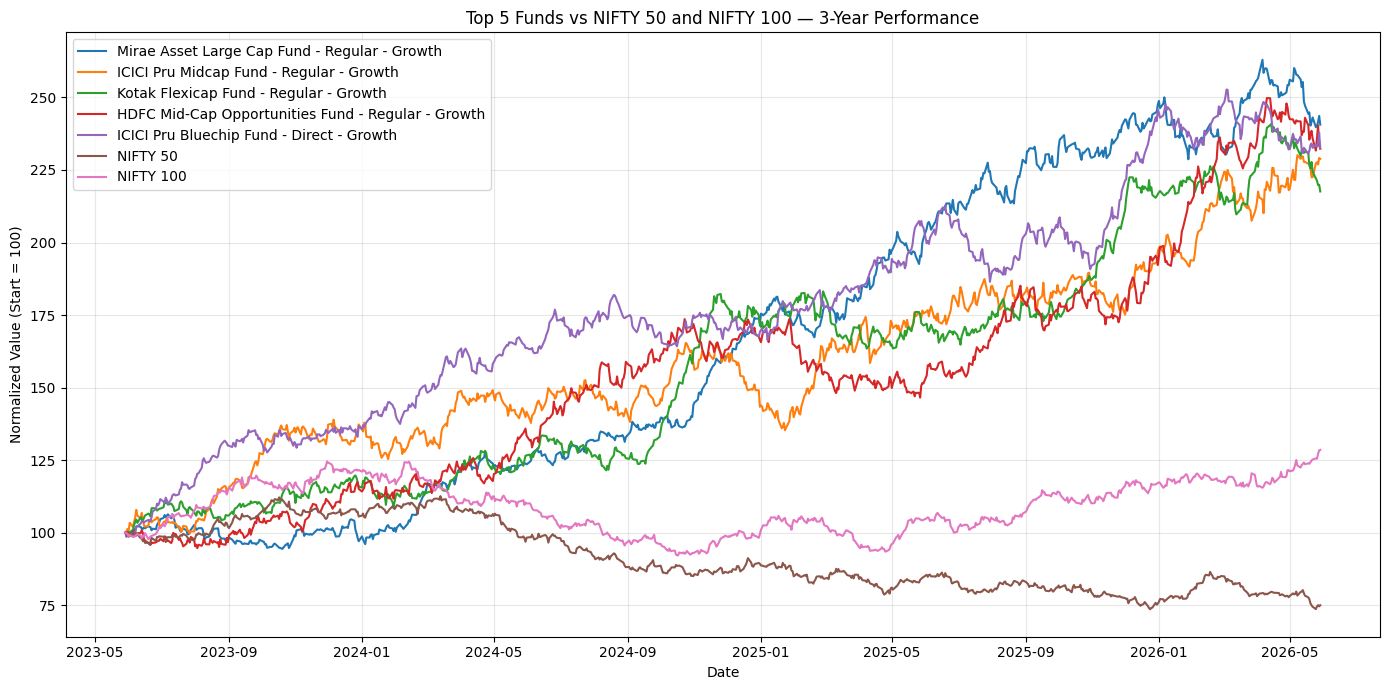

In [ ]:
# Benchmark comparison chart

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

for series in comparison_data['series_name'].unique():
    series_data = comparison_data[
        comparison_data['series_name'] == series
    ].sort_values('date')

    plt.plot(
        series_data['date'],
        series_data['normalized_value'],
        label=series
    )

plt.title('Top 5 Funds vs NIFTY 50 and NIFTY 100 — 3-Year Performance')
plt.xlabel('Date')
plt.ylabel('Normalized Value (Start = 100)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [ ]:
# Calculate Tracking Error for Top 5 Funds

tracking_error_results = []

for _, fund in top_5_funds.iterrows():

    amfi_code = fund['amfi_code']
    scheme_name = fund['scheme_name']

    fund_returns = nav_3y[
        nav_3y['amfi_code'] == amfi_code
    ][['date', 'daily_return']].dropna()

    # Merge with NIFTY 50
    merged_50 = fund_returns.merge(
        nifty50_3y[['date', 'benchmark_return']],
        on='date',
        how='inner'
    )

    # Merge with NIFTY 100
    merged_100 = fund_returns.merge(
        nifty100_3y[['date', 'benchmark_return']],
        on='date',
        how='inner'
    )

    # Tracking Error
    tracking_error_50 = (
        (merged_50['daily_return'] - merged_50['benchmark_return']).std()
        * (252 ** 0.5)
    )

    tracking_error_100 = (
        (merged_100['daily_return'] - merged_100['benchmark_return']).std()
        * (252 ** 0.5)
    )

    tracking_error_results.append({
        'amfi_code': amfi_code,
        'scheme_name': scheme_name,
        'Tracking_Error_NIFTY50': tracking_error_50,
        'Tracking_Error_NIFTY100': tracking_error_100
    })

tracking_error_report = pd.DataFrame(tracking_error_results)

print("Tracking error calculated for all Top 5 funds.")
tracking_error_report.round(4)

Tracking error calculated for all Top 5 funds.


,amfi_code,scheme_name,Tracking_Error_NIFTY50,Tracking_Error_NIFTY100
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.1918,0.1879
1,120505,ICICI Pru Midcap Fund - Regular - Growth,0.2283,0.2325
2,120843,Kotak Flexicap Fund - Regular - Growth,0.2049,0.2064
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.2281,0.2248
4,120504,ICICI Pru Bluechip Fund - Direct - Growth,0.1884,0.1873


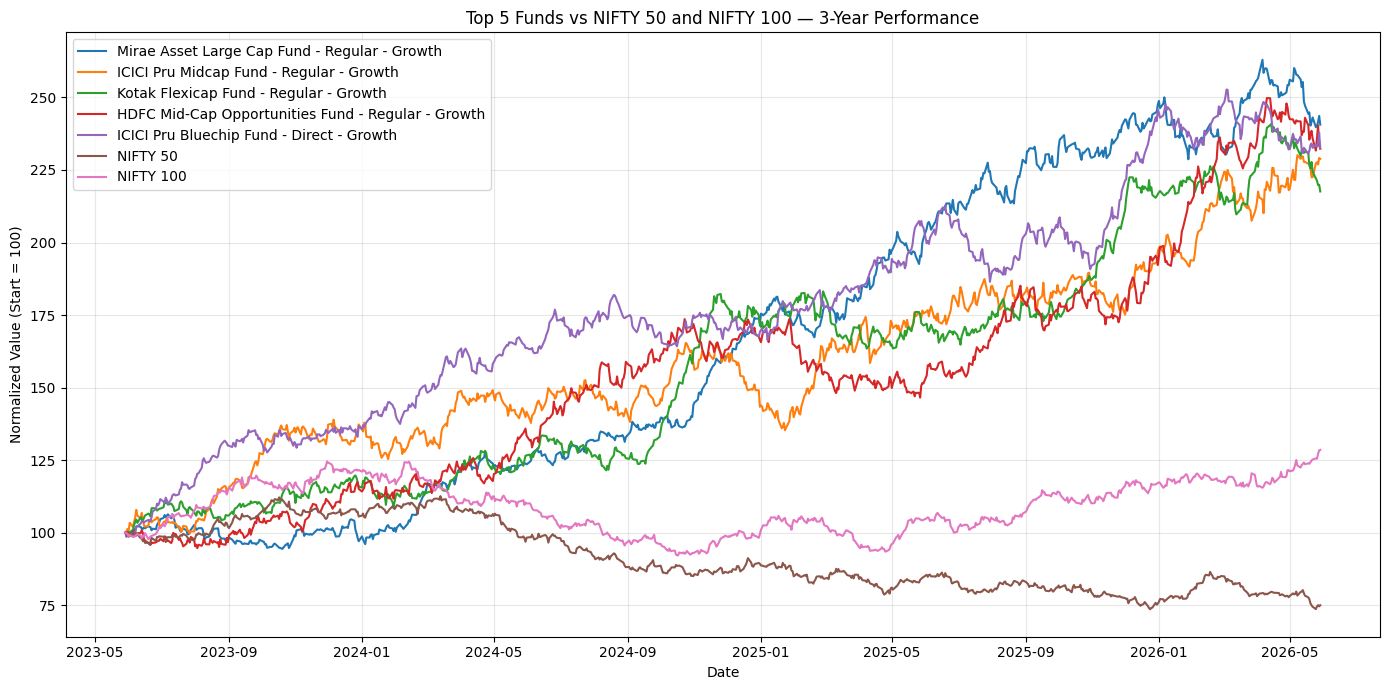

Benchmark comparison chart saved as: benchmark_comparison_3Y.png


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

for series in comparison_data['series_name'].unique():
    series_data = comparison_data[
        comparison_data['series_name'] == series
    ].sort_values('date')

    plt.plot(
        series_data['date'],
        series_data['normalized_value'],
        label=series
    )

plt.title('Top 5 Funds vs NIFTY 50 and NIFTY 100 — 3-Year Performance')
plt.xlabel('Date')
plt.ylabel('Normalized Value (Start = 100)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save the required PNG
chart_path = "benchmark_comparison_3Y.png"
plt.savefig(chart_path, dpi=300, bbox_inches='tight')

plt.show()

print("Benchmark comparison chart saved as:", chart_path)